In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [2]:
data=load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### store the predictors in and target in separate variables

In [3]:
x=data.data
y=data.target
print(x.shape)
print(y.shape)

(442, 10)
(442,)


### Prepare the data for the StatsModel module by adding a constant. One more attribute whose values is zero will be added to each row

In [4]:
x=sm.add_constant(x)
print(x.shape)

(442, 11)


### Get the columns of the data

In [5]:
columns=data.feature_names.copy()
columns.insert(0, 'constant')
print(columns)

['constant', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


### Put the data in a dataframe for easier visualization

In [6]:
df = pd.DataFrame(x, columns=columns)
df['target'] = y
df.head()

,constant,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,1.0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,1.0,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,1.0,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,1.0,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,1.0,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### show the correlation between the variables using a correlation matrix and add a title

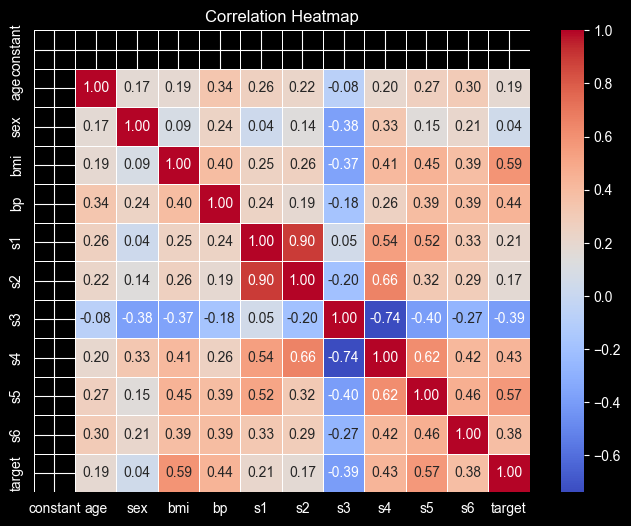

In [7]:
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

### split the data into training and test set

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
test_size=0.4, random_state=42)

### fit the model

In [9]:
model = sm.OLS(y_train, x_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     26.14
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           7.41e-34
Time:                        07:30:42   Log-Likelihood:                -1434.5
No. Observations:                 265   AIC:                             2891.
Df Residuals:                     254   BIC:                             2930.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        148.9285      3.418     43.574      0.0

### Visualize some of the predictions and compare them with the target values

In [10]:
predictions=model.predict(x_test)
for val in predictions[0:10]:
    print("{:.0f}\t".format(val), end="")
print()
for val in y_test[0:10]:
    print("{:.0f}\t".format(val), end="")

137	181	131	277	120	92	262	182	81	113	
219	70	202	230	111	84	242	272	94	96	

### view RMSE values and R-Squared values

In [11]:
rms=np.sqrt(mse(y_test,predictions))
print("RMSE: {:.2f}".format(rms))
print("R2: {:.2f}".format(model.rsquared))
print("Adjusted R2: {:.2f}".format(model.rsquared_adj))

RMSE: 53.23
R2: 0.51
Adjusted R2: 0.49


### store the coefficients and their confidence intervals in a dataframe for easier visualization. Also calculate the importance of each attribute

In [12]:
std_errors = model.bse
#95% confidence intervals for the coefficients
conf_intervs = model.conf_int()

### create a dataframe and combine for easy viewing

In [13]:
print(conf_intervs[:,0])
print(conf_intervs[:,1])
dfSummary = pd.DataFrame({
    'Variable': columns,
    'Coefficient': model.params, #Coefficient value
    'Standard Error': std_errors,
    'coeff_lb': conf_intervs[:,0],#lower bounds of the interval
    'coeff_ub': conf_intervs[:,1]#upper bounds of the interval
})
dfSummary["importance"]=dfSummary["Coefficient"]/dfSummary["Standard Error"]
dfSummary.head(11)

[  142.19754814  -139.81901453  -384.3360484    415.81933794
   194.92973784 -1675.50822162  -469.83439146  -502.19785476
  -279.50985128   148.80121778  -143.7231463 ]
[ 155.65946861  175.99500979  -69.75084913  768.7351318   528.15272699
  363.69344613 1177.26711971  531.02316414  565.25723871 1039.22963985
  207.06950568]


,Variable,Coefficient,Standard Error,coeff_lb,coeff_ub,importance
0,constant,148.928508,3.417863,142.197548,155.659469,43.573574
1,age,18.087998,80.182400,-139.819015,175.995010,0.225586
2,sex,-227.043449,79.870412,-384.336048,-69.750849,-2.842648
3,bmi,592.277235,89.602213,415.819338,768.735132,6.610074
4,bp,361.541232,84.602383,194.929738,528.152727,4.273417
5,s1,-655.907388,517.735348,-1675.508222,363.693446,-1.266878
6,s2,353.716364,418.184571,-469.834391,1177.267120,0.845838
7,s3,14.412655,262.325719,-502.197855,531.023164,0.054942
8,s4,142.873694,214.478926,-279.509851,565.257239,0.666143
9,s5,594.015429,226.071936,148.801218,1039.229640,2.627551


### sort the values

In [14]:
dfSorted=dfSummary.sort_values(by="importance", ascending=False)
dfSorted.head(11)

,Variable,Coefficient,Standard Error,coeff_lb,coeff_ub,importance
0,constant,148.928508,3.417863,142.197548,155.659469,43.573574
3,bmi,592.277235,89.602213,415.819338,768.735132,6.610074
4,bp,361.541232,84.602383,194.929738,528.152727,4.273417
9,s5,594.015429,226.071936,148.801218,1039.229640,2.627551
6,s2,353.716364,418.184571,-469.834391,1177.267120,0.845838
8,s4,142.873694,214.478926,-279.509851,565.257239,0.666143
10,s6,31.673180,89.063166,-143.723146,207.069506,0.355626
1,age,18.087998,80.182400,-139.819015,175.995010,0.225586
7,s3,14.412655,262.325719,-502.197855,531.023164,0.054942
5,s1,-655.907388,517.735348,-1675.508222,363.693446,-1.266878


### remove the intercept coefficient and its other associated information

In [15]:
lineLabels=dfSorted['Variable'].values[1:-1]
lowerBounds=dfSorted['coeff_lb'].values[1:-1]
upperBounds=dfSorted['coeff_ub'].values[1:-1]
coefficients=dfSorted['Coefficient'].values[1:-1]

importances=dfSorted['importance'].values[1:-1]

### get the minimum and the maximum of the coefficients’ upper and lower bounds. This will help in setting the dimensions of the graph and generating the axis labels

In [16]:
temp=np.array(lowerBounds)
minX=temp.min()
temp=np.array(upperBounds)
maxX=temp.max()
xvalues=np.linspace(minX, maxX, 10 , dtype='int')
temp=np.array(importances)
maxX=int(temp.max()+1)
minX=int(temp.min()-1)
yvalues=np.linspace(minX, maxX, 10, dtype='int')

In [17]:
### remove the intercept coefficient and its other associated information

In [18]:
lineLabels=dfSorted['Variable'].values[1:-1]
lowerBounds=dfSorted['coeff_lb'].values[1:-1]
upperBounds=dfSorted['coeff_ub'].values[1:-1]
coefficients=dfSorted['Coefficient'].values[1:-1]
importances=dfSorted['importance'].values[1:-1]

### get the minimum and the maximum of the coefficients’ upper and lower bounds. This will help in setting the dimensions of the graph and generating the axis labels

In [19]:
temp=np.array(lowerBounds)
minX=temp.min()
temp=np.array(upperBounds)
maxX=temp.max()
xvalues=np.linspace(minX, maxX, 10 , dtype='int')
temp=np.array(importances)
maxX=int(temp.max()+1)
minX=int(temp.min()-1)
yvalues=np.linspace(minX, maxX, 10, dtype='int')

### create the points for the horizontal/importance lines of the coefficients also a mide vertival line to show the actual coefficient values

In [20]:
left=[] #stores left points of importance lines
right=[] #stores right points of importance lines
top=[] #stores the top point of a vertical line marking coefficient location
bottom=[] #stores the bottom point of a vertical line marking coefficient location
for x,y,z,w in zip(importances, lowerBounds, upperBounds, coefficients):
    left.append([y,z])
    right.append([x,x])
    top.append([w,w])
    bottom.append([x-0.02,x+0.02])

### Plot the lines

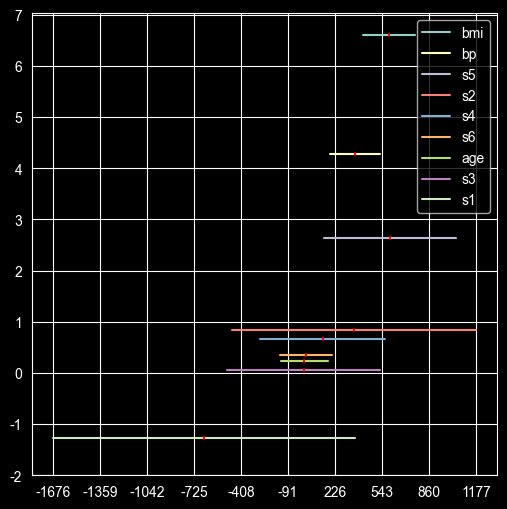

In [21]:
fig, ax = plt.subplots()
ax.figure.set_figwidth(6)
ax.figure.set_figheight(6)
for i in range(len(left)):
    ax.plot(left[i], right[i], linestyle='-', label=lineLabels[i])
    ax.plot(top[i], bottom[i], color='red')
ax.set_xticks(xvalues,xvalues)
ax.set_yticks(yvalues,yvalues)
ax.legend()

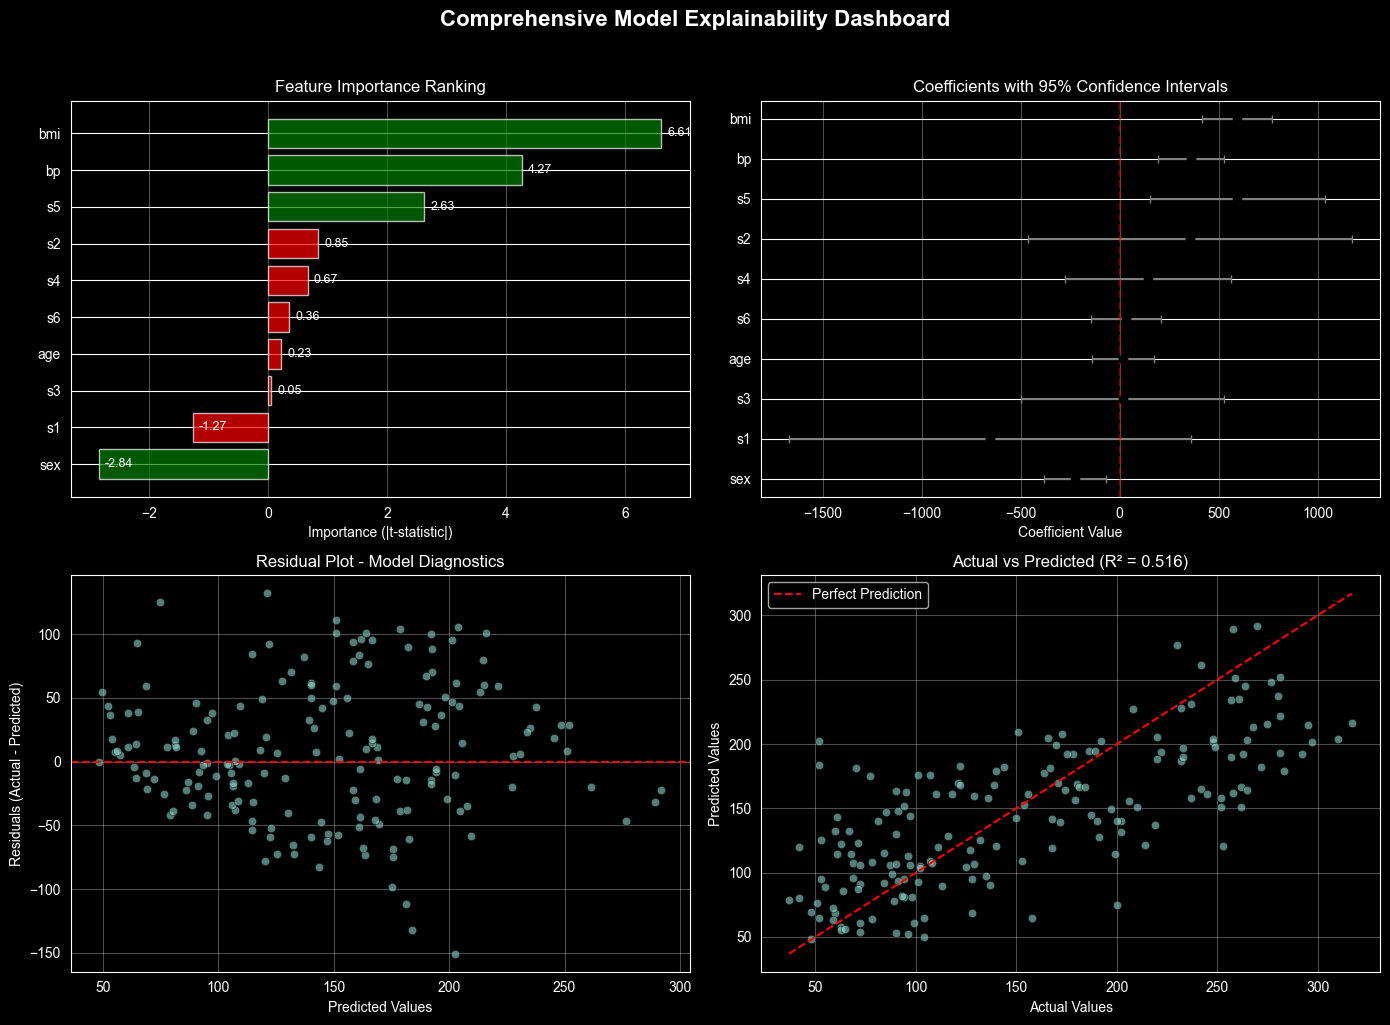

Explainability dashboard created successfully!


In [22]:

# Create a comprehensive feature importance visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature Importance Bar Chart (excluding constant)
ax1 = axes[0, 0]
dfSorted["Significant"] = (dfSorted["coeff_lb"] > 0) | (dfSorted["coeff_ub"] < 0)
features = dfSorted['Variable'].values[1:]
importance_vals = dfSorted['importance'].values[1:]
colors_bar = ['green' if sig else 'red' for sig in dfSorted['Significant'].values[1:]]

bars = ax1.barh(range(len(features)), importance_vals, color=colors_bar, alpha=0.7)
ax1.set_yticks(range(len(features)))
ax1.set_yticklabels(features)
ax1.set_xlabel('Importance (|t-statistic|)')
ax1.set_title('Feature Importance Ranking')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, importance_vals)):
    ax1.text(val + 0.1, i, f'{val:.2f}', va='center', fontsize=9)

# 2. Coefficient Values with Error Bars
ax2 = axes[0, 1]
coef_vals = dfSorted['Coefficient'].values[1:]
errors = dfSorted['Standard Error'].values[1:]
y_pos = range(len(features))

ax2.errorbar(coef_vals, y_pos, xerr=1.96*errors, fmt='o',
             color='black', ecolor='gray', capsize=3, markersize=6)
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(features)
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Coefficients with 95% Confidence Intervals')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# 3. Residual Analysis
ax3 = axes[1, 0]
residuals = y_test - predictions
ax3.scatter(predictions, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
ax3.axhline(y=0, color='red', linestyle='--')
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals (Actual - Predicted)')
ax3.set_title('Residual Plot - Model Diagnostics')
ax3.grid(alpha=0.3)

# 4. Actual vs Predicted
ax4 = axes[1, 1]
ax4.scatter(y_test, predictions, alpha=0.6, edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
ax4.set_xlabel('Actual Values')
ax4.set_ylabel('Predicted Values')
ax4.set_title(f'Actual vs Predicted (R² = {r2_score(y_test, predictions):.3f})')
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle('Comprehensive Model Explainability Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Explainability dashboard created successfully!")
